# 1. Install library

In [1]:
!pip install mmcfilters
!pip install bokeh
!pip install morphotreeviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 29.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mmcfilters: filename=mmcfilters-0.1.19-cp312-cp312-linux_x86_64.whl size=388169 sha256=fd6d094b0591ffcc1e87fd431ff713457ae9e633b23bf3774abb1f5e936aee73
  Stored in directory: /root/.cache/pip/wheels/88/67/9e/16f9533e55ed3002eff335814a64f227d4b5de03d0e8c541f3
Successfully built mmcfilters
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.4 MB/s eta 0:00:00


# 2. Importing library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv
import mmcfilters
import mtviz as viz

from bokeh.io import output_notebook, show
from bokeh.layouts import column, row
output_notebook()

def getPlotTree(root, title):
    return viz.makePlotTree(
        root,
        lambda n: n.children,
        {
            "id:": lambda n: n.id,
            "level:": lambda n: n.level,
            "area:": lambda n: n.area,
        },
        lambda n: n.id,
        panel_caption = title
    ).panel




Loading BokehJS ...

# 3. Creating the morphological tree of an input image

In [5]:
#imgInput = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)

imgInput = np.array([
        [203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203],
        [203,203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203,203],
        [203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203],
        [203,203, 78, 78,126,126,126,126,126,126,126, 78, 78, 78, 78, 78, 78, 78,203,203,203, 54, 54,203,203],
        [203,203, 78, 78,126, 38, 38, 38,126,126,126, 78, 78, 78, 78, 78, 78, 78,203,203, 54, 54, 54, 54,203],
        [203,203, 78, 78,126, 38, 38, 38,126,126,126, 78, 78, 78, 78, 78, 78, 78,203, 54, 54, 54, 80, 54,203],
        [203,203, 78, 78,126, 38, 38, 38,126, 78, 78, 78, 78, 78, 78, 78, 78, 78,203, 54, 80, 54, 54, 54,203],
        [203, 78, 78, 78,126, 38, 38,126,126, 78, 78, 78,203,203,203,203,203,203,203, 54, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126,126, 78, 78,203,203,203,203,203,203,203,203, 54, 54, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,253,253,253,203,203,203, 54, 80, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,253,253,253,203,203, 54, 54, 54, 54, 54,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,253,253,253,203,203,203, 54, 54, 54,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,203,203,203,203,203,203,203,203,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,203,126,126,126,126,203,203,203,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,126,126,126,126,126,126,126,126,126,203,203,203],
        [203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,126,126,126,126,126,126, 72,126,126,203,203,203],
        [203, 78, 78, 78, 78, 78, 78,161,161,161, 78, 78,203,126,126,126,126,126,126, 72, 72,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78,203,126,126,126,126,126, 72, 72, 72,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 30, 30,161, 78,203,203,126,126,126, 72, 72, 72, 72, 72,126,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 90, 30,161, 78, 78,203,126,126, 72, 72, 72, 72, 72, 72, 72,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 30, 30,161, 78, 78,203,203,126,126,126,126,126,126,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78, 78, 78,203,203,126,126,126,126,126,126,126,203,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78, 78, 78,203,203,203,203,126,126,126,126,203,203,203],
        [203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203,203,203,203],
        [203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203]
], dtype=np.uint8)
(num_rows, num_cols) = imgInput.shape

isMaxtree = False
tree = mmcfilters.MorphologicalTree(imgInput, isMaxtree)
Type = mmcfilters.Attribute.Type

viz.showLevelSets(imgInput)


In [7]:
viz.showComponentTree(tree.root,image=imgInput)

# 4. Available attributes

In [ ]:
describe = {}
for atributo, valor in Type.__dict__.items():
    if(str(valor).startswith("Type.")):
        describe[str(valor).split('.')[1]] = mmcfilters.Attribute.describe(valor)

df = pd.DataFrame(describe.items(), columns=['Attribute type', 'Description'])
df.style.set_caption("<H3><b>Available attributes</b></H3>")

,Attribute type,Description
0,AREA,Area: Number of pixels in the connected component.
1,VOLUME,"Volume: Sum of the gray-level intensities of all pixels in the connected component. Interpreted as the total mass under the component, or the integral of the image function over its support."
2,RELATIVE_VOLUME,Relative volume: Sum of differences between the node level and the gray-levels of pixels in the component. Measures the amount of intensity required to fill the component to its node level.
3,LEVEL,Level: Gray-level at which the connected component appears in the threshold decomposition hierarchy; corresponds to the altitude of the node in the component tree.
4,GRAY_HEIGHT,"GRAY_HEIGHT: For a node in the max-tree, the difference between its level and the maximum level among its descendants; analogously, in the min-tree, the difference to the minimum level among its descendants."
5,MEAN_LEVEL,Mean level: Average gray-level intensity of the pixels in the connected component.
6,VARIANCE_LEVEL,Variance of level: Variance of the gray-level values of the pixels in the connected component.
7,BOX_WIDTH,Bounding box width: Width of the minimum rectangle enclosing the connected component.
8,BOX_HEIGHT,Bounding box height: Height of the minimum rectangle enclosing the connected component.
9,RECTANGULARITY,Rectangularity: Ratio between the connected component area and the area of its bounding box. Values closer to 1 indicate shapes that efficiently fill their bounding box.


# 5. Computing a single attribute

In [ ]:
Type = mmcfilters.Attribute.Type

attrType = Type.GRAY_HEIGHT
attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, attrType)

print(f"{attrType.name} (numpy): {attrValue}")

GRAY_HEIGHT (numpy): [224. 174. 132.  89.  55.  61.  27.   0.   0.   0.   0.   0.]


In [ ]:
viz.showTree(tree, printTreeWithAttribute(attrType, attrValue))

# 6. Computing multiple attribute

In [ ]:
Type = mmcfilters.Attribute.Type

dic, attrs = mmcfilters.Attribute.computeAttributes(tree, [Type.AREA, Type.GRAY_HEIGHT, Type.VOLUME, Type.RELATIVE_VOLUME])
#print(attrs[:, dic['GRAY_HEIGHT']])
pd.DataFrame(attrs, columns=dic, index=pd.Index(range(len(attrs)), name="NodeID"))

,AREA,VOLUME,RELATIVE_VOLUME,GRAY_HEIGHT
NodeID,,,,
0,625.0,82872.0,77409.0,224.0
1,616.0,80595.0,45984.0,174.0
2,277.0,24802.0,20535.0,132.0
3,244.0,20608.0,10582.0,89.0
4,84.0,9612.0,1074.0,55.0
5,9.0,330.0,497.0,61.0
6,38.0,2130.0,983.0,27.0
7,191.0,14898.0,191.0,0.0
8,18.0,1296.0,18.0,0.0


# 7. Attribute filtering

Text(0.5, 1.0, 'attribute filter')

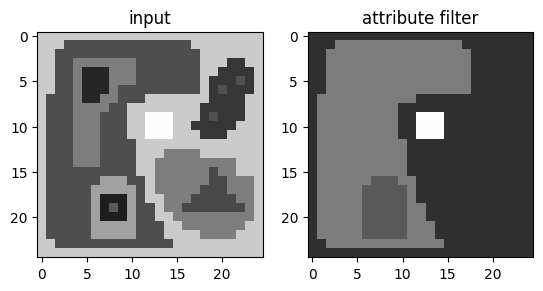

In [ ]:
attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, Type.GRAY_HEIGHT)
threshold = 80

attFilter = mmcfilters.AttributeFilters(tree)
imgFiltered = attFilter.filteringSubtractiveRule(attrValue > threshold)

plt.subplot(1,2, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,2, 2)
plt.imshow(imgFiltered.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter')

# 8. Extraction of extinction values

In [ ]:
attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, Type.GRAY_HEIGHT) #o atributo precisa ser crescente

In [ ]:
extinctionValues = mmcfilters.ExtinctionValues(tree, attrValue)
for (leaf, cutoffNode, extinction) in extinctionValues.getExtinctionValues():
    print("Regional extrema (folha):", leaf)
    print("Valor do extincao: ", extinction)
    print("Local (persistencia) que a regional extrema ainda existir:", cutoffNode)
    print("A regional extrema não existem em:", cutoffNode.parent)
    print()

showComponentTree(tree.root,image=imgInput, )

Regional extrema (folha): NodeMT(id=11, level=30, numCNPs=8, area=8)
Valor do extincao:  61.0
Local (persistencia) que a regional extrema ainda existir: NodeMT(id=5, level=90, numCNPs=1, area=9)
A regional extrema não existem em: NodeMT(id=2, level=161, numCNPs=24, area=277)

Regional extrema (folha): NodeMT(id=8, level=72, numCNPs=18, area=18)
Valor do extincao:  55.0
Local (persistencia) que a regional extrema ainda existir: NodeMT(id=4, level=126, numCNPs=66, area=84)
A regional extrema não existem em: NodeMT(id=1, level=203, numCNPs=217, area=616)

Regional extrema (folha): NodeMT(id=9, level=54, numCNPs=35, area=35)
Valor do extincao:  27.0
Local (persistencia) que a regional extrema ainda existir: NodeMT(id=6, level=80, numCNPs=3, area=38)
A regional extrema não existem em: NodeMT(id=1, level=203, numCNPs=217, area=616)

Regional extrema (folha): NodeMT(id=7, level=78, numCNPs=191, area=191)
Valor do extincao:  0.0
Local (persistencia) que a regional extrema ainda existir: NodeMT

# 9. Filtering by extinction values
  > Idea: Keep the k regional extremes with the highest extinction values ​​in the image

Text(0.5, 1.0, 'keeping 3 regional extremes')

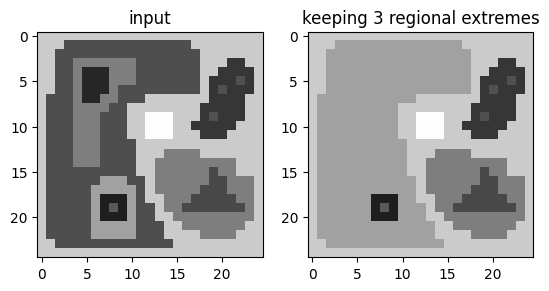

In [ ]:
attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, Type.GRAY_HEIGHT)
attFilter = mmcfilters.AttributeFilters(tree)

numLeafToKeep = 3 #mantem numLeafToKeep folhas com maiores valores de extinção
imgFiltered = attFilter.filteringByExtinction(attrValue, numLeafToKeep)

plt.subplot(1,2, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,2, 2)
plt.imshow(imgFiltered, cmap='gray', vmax=255, vmin=0)
plt.title('keeping 3 regional extremes')

# 10. Playing with the coin image

Text(0.5, 1.0, 'attribute filter')

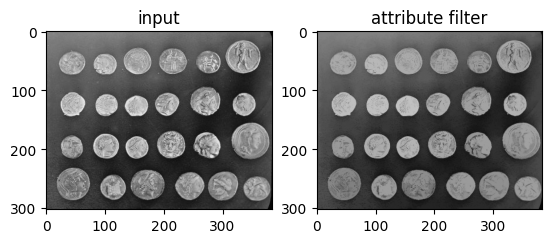

In [ ]:
# 1. Filteing

from skimage import data, img_as_float
imgInput = data.coins()
(num_rows, num_cols) = imgInput.shape

isMaxtree = True
tree = mmcfilters.MorphologicalTree(imgInput, isMaxtree)

attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, Type.AREA)
threshold = 500

attFilter = mmcfilters.AttributeFilters(tree)
imgFiltered = attFilter.filteringSubtractiveRule(attrValue > threshold)

plt.subplot(1,2, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,2, 2)
plt.imshow(imgFiltered, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter')

Text(0.5, 1.0, 'keeping 24 regional extremes')

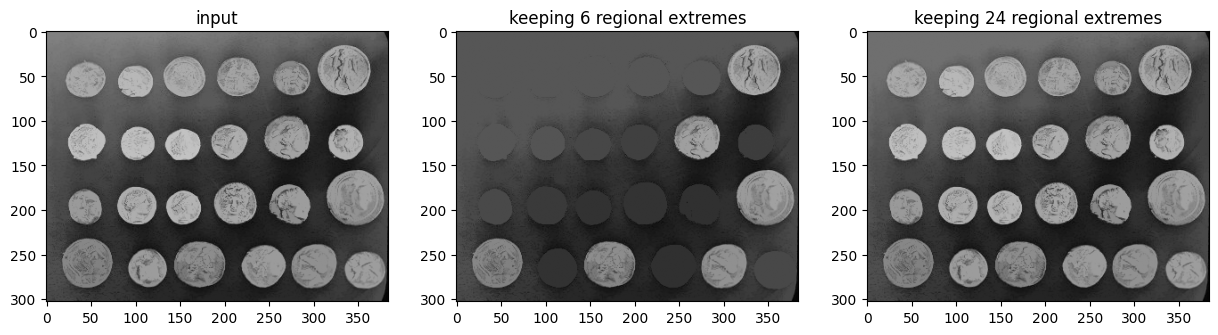

In [ ]:
#2. filtering by extinction values

imgInput = imgFiltered

isMaxtree = True
tree = mmcfilters.MorphologicalTree(imgInput, isMaxtree)
attFilter = mmcfilters.AttributeFilters(tree)
attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, Type.AREA)

numLeafToKeep = 6 #mantem numLeafToKeep folhas com maiores valores de extinção
imgFiltered6 = attFilter.filteringByExtinction(attrValue, numLeafToKeep)

numLeafToKeep = 24 #mantem numLeafToKeep folhas com maiores valores de extinção
imgFiltered24 = attFilter.filteringByExtinction(attrValue, numLeafToKeep)

plt.figure(figsize=(15, 5))
plt.subplot(1,3, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,3, 2)
plt.imshow(imgFiltered6, cmap='gray', vmax=255, vmin=0)
plt.title('keeping 6 regional extremes')

plt.subplot(1,3,3)
plt.imshow(imgFiltered24, cmap='gray', vmax=255, vmin=0)
plt.title('keeping 24 regional extremes')

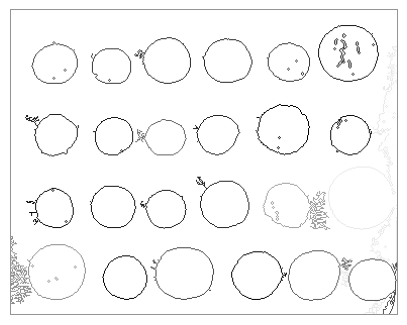

In [ ]:
# 3. Creating a saliency map

attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, Type.AREA)
circularity = mmcfilters.Attribute.computeSingleAttribute(tree, Type.CIRCULARITY)
extinctionValues = mmcfilters.ExtinctionValues(tree, attrValue) #o atributo precisa ser crescente
numLeafToKeep = int(len(tree.leaves) * 1) #5% das extremas regionais

countors = mmcfilters.ContourComputation.extraction(tree)

contour_img = np.zeros((num_rows*num_cols), dtype=np.float32)
importance = numLeafToKeep
for leaf, cutoffNode, extinction in sorted(extinctionValues.getExtinctionValues(), key=lambda x: x[2], reverse=True)[:numLeafToKeep]:
    for p in countors.getContour(cutoffNode.id):
        contour_img[p]= circularity[cutoffNode.id]
        #contour_img[p]= importance
    importance -= 1


plt.figure(figsize=(5, 5))
plt.imshow(contour_img.reshape(num_rows, num_cols), cmap='Grays')
plt.axis('off')
plt.show()

# Essa abordagem é limitada a uma atributo crescente!!!

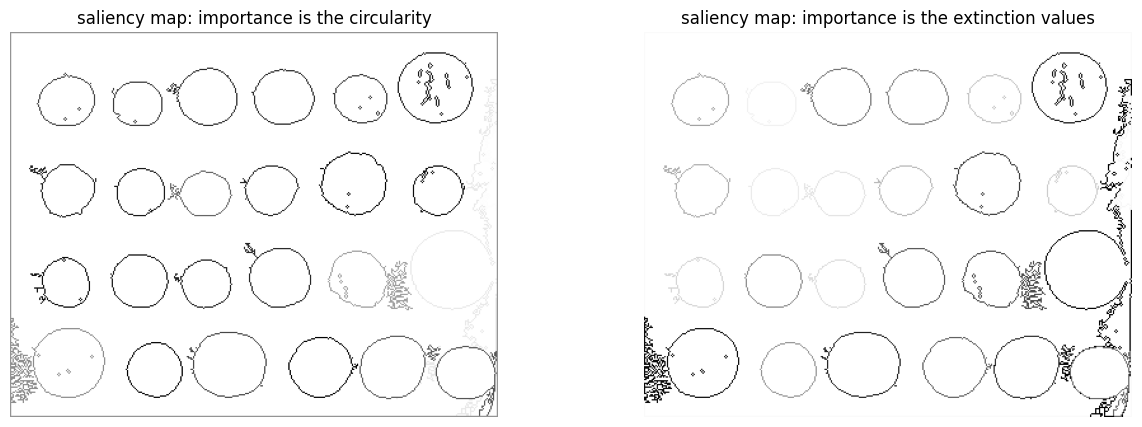

In [ ]:
attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, Type.AREA)
circularity = mmcfilters.Attribute.computeSingleAttribute(tree, Type.CIRCULARITY)
extinctionValues = mmcfilters.ExtinctionValues(tree, attrValue) #o atributo precisa ser crescente
numLeafToKeep = int(len(tree.leaves) * 1)

countors = mmcfilters.ContourComputation.extraction(tree)

contour_img = np.zeros((num_rows*num_cols), dtype=np.float32)
importance = numLeafToKeep
for leaf, cutoffNode, extinction in sorted(extinctionValues.getExtinctionValues(), key=lambda x: x[2], reverse=True)[:numLeafToKeep]:
    for p in countors.getContour(cutoffNode.id):
        contour_img[p]=circularity[cutoffNode.id]
    importance -= 1



plt.figure(figsize=(15, 5))
plt.subplot(1,2, 1)
plt.imshow(contour_img.reshape(num_rows, num_cols), cmap='Grays')
plt.axis('off')
plt.title('saliency map: importance is the circularity')

plt.subplot(1,2, 2)
saliencyMap = extinctionValues.saliencyMap(numLeafToKeep)
plt.imshow(saliencyMap, cmap='Grays')
plt.axis('off')
plt.title('saliency map: importance is the extinction values')
plt.show()
